In [5]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as pl
from matplotlib.patches import Circle

$$
\begin{aligned}
\arg\min_{x \in \mathbb{R}^{m \times n}} \quad & \frac{1}{2}\|Hx - y\|_2^2 \\
\text{subject to} \quad & x \ge 0 \\
& x \le 1
\end{aligned}
$$

In [6]:
numRows = 5
numCols = 3

mH = np.random.randn(numRows, numCols)
vY = np.random.randn(numRows)

vX = cp.Variable(numCols)

cpObjFun = cp.Minimize(cp.sum_squares(mH @ vX - vY))
cpConst = [vX <=1.0, vX >= 0.0]
oCvxPrb = cp.Problem(cpObjFun, cpConst)
oCvxPrb.solve(solver = cp.CLARABEL)
vX.value

array([8.35507292e-02, 2.12469612e-01, 2.23568634e-10])

In [7]:
numSamples = 20
dim = 2
np.random.seed(1)
mX = np.random.randn(numSamples, dim) - 0.5

In [8]:
fig, ax = plt.subplots()
ax.scatter(mX[:, 0], mX[:, 1])
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.show()


NameError: name 'plt' is not defined

In [ ]:
vC = cp.Variable(dim) # center of circle (Define the first variable(provide dimensions))
vR = cp.Variable(1) # radius - scalar (Devine the second variable)

cpObjFun = cp.Minimize(vR) # define the objective function and the goal to minimize
cpConst = [cp.norm(row - vC) <= vR for row in mX] # define the list of restrictions, functions must be taken from cvxpy atoms
o_problem = cp.Problem(cpObjFun, cpConst) # creation of object problem
o_problem.solve(solver=cp.CLARABEL) #sending to solver

assert (oCvxPrb.status == 'optimal'), 'The problem is not solved.' # varification
print('Problem is solved.')

Problem is solved.


In [ ]:
vC = vC.value
print(f" the center in = {vC}")
vR = vR.value
print(f"The radius is {vR}")

 the center in = [-0.31922384 -0.95768308]
The radius is [2.05175085]


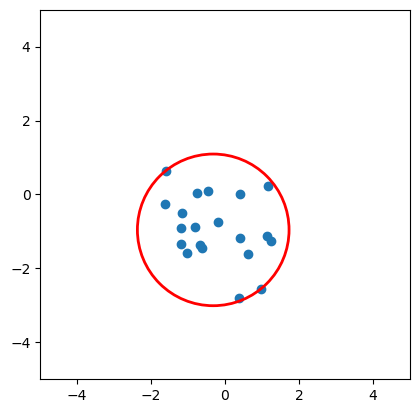

In [ ]:
fig, ax = plt.subplots()
ax.scatter(mX[:, 0], mX[:, 1])
circle = Circle(vC, vR, color='red', fill=False, lw=2 )
ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.show()

In [ ]:
numSamples = 25
numOutlayers = 6

noise_std = 0.05
outlayers_sdt = 2.5

# Model ax + b
modelSlope      = 1
modelIntercept  = 0

# Verification
ε      = 1e-6 #<! Error threshold


In [ ]:
vG = np.random.randn(numSamples + numOutlayers)
vB = vG * modelSlope + modelIntercept + noise_std * np.random.randn(numSamples + numOutlayers)
vI = np.random.choice(numSamples + numOutlayers, numOutlayers)
vB[vI] = vB[vI] + outlayers_sdt * vB[vI]

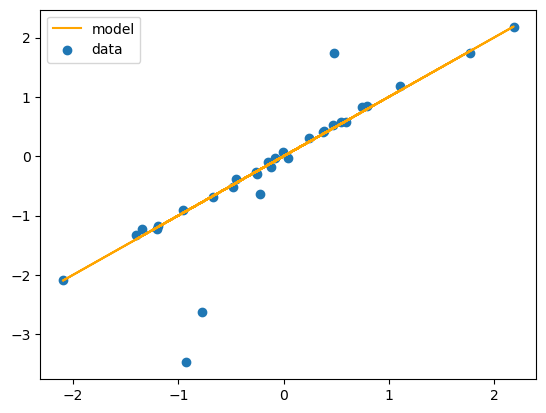

In [ ]:
fig, ax = plt.subplots()
ax.plot(vG, vG * modelSlope + modelIntercept, label='model', color = 'orange')
ax.scatter(vG, vB, label = 'data')
plt.legend()
plt.show()

In [ ]:
mA = np.array([vG, np.ones(len(vG))]).T
w, *_ = np.linalg.lstsq(mA, vB)
w

array([ 1.15678547, -0.08096107])

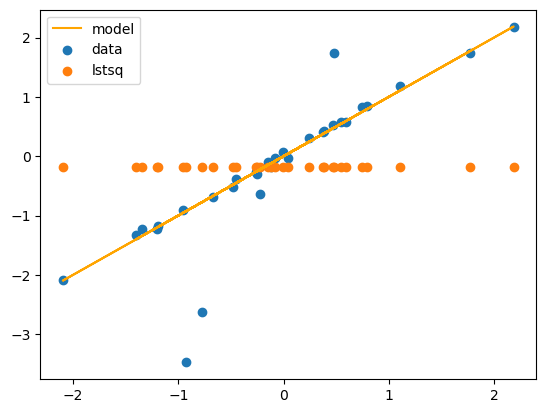

In [ ]:
fig, ax = plt.subplots()
ax.plot(vG, vG * modelSlope + modelIntercept, label='model', color = 'orange')
ax.scatter(vG, vB, label = 'data')
ax.scatter(vG, vG * w[0] + w[1], label = 'lstsq')
plt.legend()
plt.show()

In [ ]:
# now i want to find aproper model usin norma1 with cvxpy Aw - b

vW = cp.Variable(2)

oFun = cp.Minimize(cp.norm(mA @ vW - vB, 1))
o_problem = cp.Problem(oFun)
o_problem.solve(solver=cp.CLARABEL) #sending to solver

assert (oCvxPrb.status == 'optimal'), 'The problem is not solved.' # varification
print('Problem is solved.')

Problem is solved.


In [ ]:
vW_cvxpy = vW.value

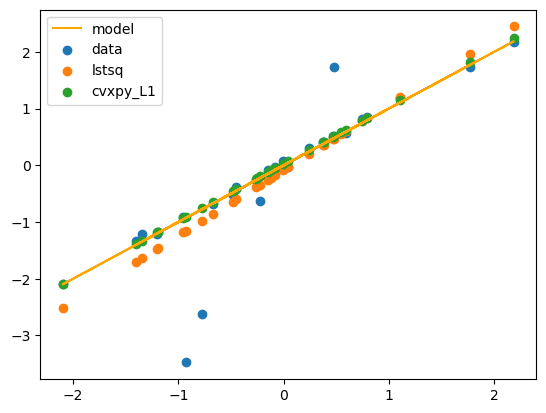

In [ ]:
fig, ax = plt.subplots()
ax.plot(vG, vG * modelSlope + modelIntercept, label='model', color = 'orange')
ax.scatter(vG, vB, label = 'data')
ax.scatter(vG, vG * w[0] + w[1], label = 'lstsq')
ax.scatter(vG, vG * vW_cvxpy[0] + vW_cvxpy[1], label = 'cvxpy_L1'  )
plt.legend()
plt.show()

In [ ]:
# now we want to solve the same progtam withlinear programing

vT = cp.Variable(mA.shape[0])

oObjectFun = cp.Minimize(cp.sum(vT))
contraints = [mA @ vG - vB <= vT, vB - mA @ vG <= vT]
problem = cp.Problem(oObjectFun, contraints)
problem.solve(solver=cp.CLARABEL)

assert (problem.status == 'optimal'), 'The problem is not solved.' # varification
print('Problem is solved.')

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 31 is different from 2)